\# MSCS 634 \- Advanced Big Data and Data Mining

\#\# Lab 3: Clustering Analysis using K\-Means and K\-Medoids

\*\*Student Name:\*\* Nabiha Sadaf

\*\*Course:\*\* MSCS 634 \- Advanced Big Data and Data Mining

\-\-\-

\#\# Objective

The objective of this lab is to perform clustering analysis using the Wine dataset from Scikit\-learn\. Two clustering algorithms, K\-Means and K\-Medoids, will be implemented and compared using evaluation metrics such as the Silhouette Score and Adjusted Rand Index \(ARI\)\. The clustering results will also be visualized to analyze the quality of the generated clusters\.

In [1]:
# Install the required package for K-Medoids

!pip install scikit-learn-extra


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Import the required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn_extra.cluster import KMedoids

from sklearn.metrics import silhouette_score

from sklearn.metrics import adjusted_rand_score

In [5]:
# Load the Wine dataset

wine = load_wine()

X = wine.data

y = wine.target

feature_names = wine.feature_names

wine_df = pd.DataFrame(X, columns=feature_names)

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
# Display dataset information

print("Dataset Shape:")

print(wine_df.shape)

print()

print("Feature Names:")

print(feature_names)

print()

print("Target Classes:")

print(wine.target_names)

Dataset Shape:
(178, 13)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Classes:
['class_0' 'class_1' 'class_2']


In [9]:
# Display class distribution

pd.Series(y).value_counts()

1    71
0    59
2    48
Name: count, dtype: int64

In [11]:
# Standardize the dataset using Z-score normalization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization Completed Successfully!")

print()

print(X_scaled[:5])

Standardization Completed Successfully!

[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


## Step 2: Implement K\-Means Clustering 

Code Cell 1: Train the K\-Means Model

Comment: Train the K\-Means clustering model with k = 3\.

In [13]:
# Train the K-Means clustering model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

kmeans_labels = kmeans.labels_

print("K-Means clustering completed successfully!")

K-Means clustering completed successfully!


Code Cell 2: Display Cluster Labels

Comment: Display the first 20 cluster labels assigned by K\-Means\.

In [15]:
# Display the first 20 cluster labels

print("First 20 Cluster Labels:")

print(kmeans_labels[:20])

First 20 Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


Code Cell 3: Calculate the Silhouette Score

Comment: Calculate the Silhouette Score for K\-Means clustering\.

In [17]:
# Calculate the Silhouette Score

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:")

print(round(kmeans_silhouette,4))

Silhouette Score:
0.2849


Code Cell 4: Calculate the Adjusted Rand Index \(ARI\)

Comment: Compare the predicted clusters with the actual wine classes using ARI\.

In [19]:
# Calculate the Adjusted Rand Index (ARI)

kmeans_ari = adjusted_rand_score(
    y,
    kmeans_labels
)

print("Adjusted Rand Index (ARI):")

print(round(kmeans_ari,4))

Adjusted Rand Index (ARI):
0.8975


Code Cell 5: Display Both Metrics Together

Comment: Display the evaluation metrics for the K\-Means clustering model\.

In [21]:
# Display K-Means evaluation metrics

print("========== K-Means Evaluation ==========")

print(f"Silhouette Score : {kmeans_silhouette:.4f}")

print(f"Adjusted Rand Index : {kmeans_ari:.4f}")

========== K-Means Evaluation ==========
Silhouette Score : 0.2849
Adjusted Rand Index : 0.8975


Code Cell 6: Display Cluster Centers

Comment: Display the cluster centroids obtained from the K\-Means model\.

In [23]:
# Display K-Means cluster centers

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_names
)

centers

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,-0.926072,-0.394042,-0.494517,0.170602,-0.491712,-0.075983,0.020813,-0.033534,0.058266,-0.901914,0.461804,0.270764,-0.753846
1,0.164907,0.871547,0.186898,0.524367,-0.075473,-0.979330,-1.215248,0.726064,-0.779706,0.941539,-1.164789,-1.292412,-0.407088
2,0.835232,-0.303810,0.364706,-0.610191,0.577587,0.885237,0.977820,-0.562090,0.580287,0.171063,0.473984,0.779247,1.125185


Code Cell 7: Display Number of Samples in Each Cluster

Comment: Display the number of observations assigned to each K\-Means cluster\.

In [25]:
# Display the number of samples in each cluster

cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print("Number of Samples in Each Cluster")

cluster_counts

Number of Samples in Each Cluster


0    65
1    51
2    62
Name: count, dtype: int64

### STEP 3: Implement K\-Medoids Clustering

Code Cell 1 – Train the K\-Medoids Model

Comment: Train the K\-Medoids clustering model with k = 3\.

In [27]:
# Train the K-Medoids clustering model

kmedoids = KMedoids(
    n_clusters=3,
    random_state=42
)

kmedoids.fit(X_scaled)

kmedoids_labels = kmedoids.labels_

print("K-Medoids clustering completed successfully!")

K-Medoids clustering completed successfully!


Code Cell 2 – Display Cluster Labels

Comment: Display the first 20 cluster labels assigned by K\-Medoids\.

In [29]:
# Display the first 20 cluster labels

print("First 20 Cluster Labels:")

print(kmedoids_labels[:20])

First 20 Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


Code Cell 3: Calculate the Silhouette Score

Comment: Calculate the Silhouette Score for K\-Medoids clustering\.

In [31]:
# Calculate the Silhouette Score

kmedoids_silhouette = silhouette_score(
    X_scaled,
    kmedoids_labels
)

print("Silhouette Score:")

print(round(kmedoids_silhouette,4))

Silhouette Score:
0.266


Code Cell 4: Calculate the Adjusted Rand Index \(ARI\)

Comment: Compare the K\-Medoids clusters with the actual wine classes\.

In [33]:
# Calculate the Adjusted Rand Index (ARI)

kmedoids_ari = adjusted_rand_score(
    y,
    kmedoids_labels
)

print("Adjusted Rand Index (ARI):")

print(round(kmedoids_ari,4))

Adjusted Rand Index (ARI):
0.7263


Code Cell 5: Display Both Evaluation Metrics

Comment: Display the evaluation metrics for K\-Medoids\.

In [35]:
# Display K-Medoids evaluation metrics

print("========== K-Medoids Evaluation ==========")

print(f"Silhouette Score : {kmedoids_silhouette:.4f}")

print(f"Adjusted Rand Index : {kmedoids_ari:.4f}")

========== K-Medoids Evaluation ==========
Silhouette Score : 0.2660
Adjusted Rand Index : 0.7263


Code Cell 6: Display the Medoids

Comment: Display the medoid coordinates\.

In [37]:
# Display the medoid coordinates

medoids = pd.DataFrame(
    kmedoids.cluster_centers_,
    columns=feature_names
)

medoids

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
1,-0.927212,-0.544297,-0.901103,-0.148624,-1.386122,-1.033684,0.000733,0.065639,0.068508,-0.717240,0.186684,0.788587,-0.754385
2,0.592164,-0.472483,0.158946,0.301803,0.018145,0.648764,0.954502,-0.820719,0.471488,0.018129,0.362177,1.212320,0.551257


Code Cell 7: Display Cluster Counts

Comment: Display the number of samples assigned to each K\-Medoids cluster\.

In [39]:
# Display cluster counts

cluster_counts = pd.Series(kmedoids_labels).value_counts().sort_index()

print("Number of Samples in Each Cluster")

cluster_counts

Number of Samples in Each Cluster


0    51
1    54
2    73
Name: count, dtype: int64

### STEP 4: Visualize and Compare Results

Code Cell 1: Create Side\-by\-Side Scatter Plots

Comment: Visualize K\-Means and K\-Medoids clustering results\.

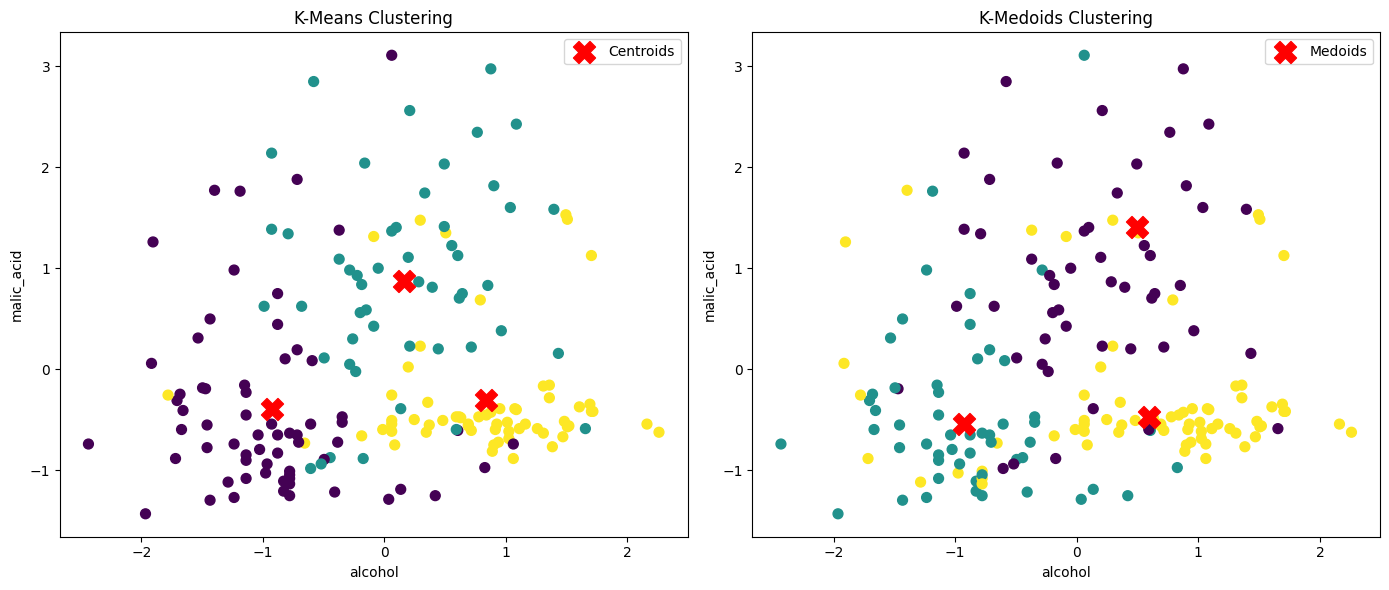

In [41]:
# Create side-by-side scatter plots

plt.figure(figsize=(14,6))

# K-Means Plot
plt.subplot(1,2,1)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels,
    cmap='viridis',
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("K-Means Clustering")

plt.xlabel(feature_names[0])

plt.ylabel(feature_names[1])

plt.legend()

# K-Medoids Plot
plt.subplot(1,2,2)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmedoids_labels,
    cmap='viridis',
    s=50
)

plt.scatter(
    kmedoids.cluster_centers_[:,0],
    kmedoids.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250,
    label='Medoids'
)

plt.title("K-Medoids Clustering")

plt.xlabel(feature_names[0])

plt.ylabel(feature_names[1])

plt.legend()

plt.tight_layout()

plt.show()

Code Cell 2: Compare the Results

Comment: Compare K\-Means and K\-Medoids using the evaluation metrics\.

In [43]:
# Compare both clustering algorithms

comparison = pd.DataFrame({
    "Algorithm":["K-Means","K-Medoids"],
    "Silhouette Score":[kmeans_silhouette,kmedoids_silhouette],
    "Adjusted Rand Index":[kmeans_ari,kmedoids_ari]
})

comparison

,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.265977,0.726341


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=51f9bf39-26fc-4a3e-99b2-052134a51d29' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>